# Pulse of Prevention: Heart Health Data Analysis

## Introduction

Heart disease remains one of the leading causes of death worldwide. Early identification of risk factors can significantly improve patient outcomes and reduce healthcare costs.

This project analyzes patient demographic and clinical data to understand the major factors associated with heart disease. The analysis aims to identify high-risk patient profiles, explore relationships between medical indicators, and provide actionable recommendations that can support preventive healthcare initiatives.

# Objectives

The primary objective of this analysis is to understand the characteristics of patients diagnosed with heart disease and identify the factors that may increase cardiovascular risk.

Specific goals include:

- Understanding the demographic profile of patients.
- Exploring clinical measurements such as cholesterol, blood pressure, and heart rate.
- Identifying variables strongly associated with heart disease.
- Comparing patients with and without heart disease.
- Developing insights that can support early diagnosis and preventive care.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')
pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv('heart.csv')

In [3]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [4]:
df.shape

(1025, 14)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [6]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


### Initial Observations

- The dataset contains demographic and clinical information of patients.
- The target variable indicates the presence or absence of heart disease.
- Both categorical and numerical features are available for analysis.
- Several variables may contribute to cardiovascular risk and require further investigation.

# Data Cleaning and Preprocessing

In [7]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

### Observation

The dataset was checked for missing values across all columns. Any missing or inconsistent values would be addressed before performing further analysis.

In [8]:
df.duplicated().sum()

723

In [9]:
df.drop_duplicates(inplace=True)

In [10]:
df.shape

(302, 14)

### Observation

Duplicate records were removed to ensure accurate analysis and avoid bias in the results.

### EDA

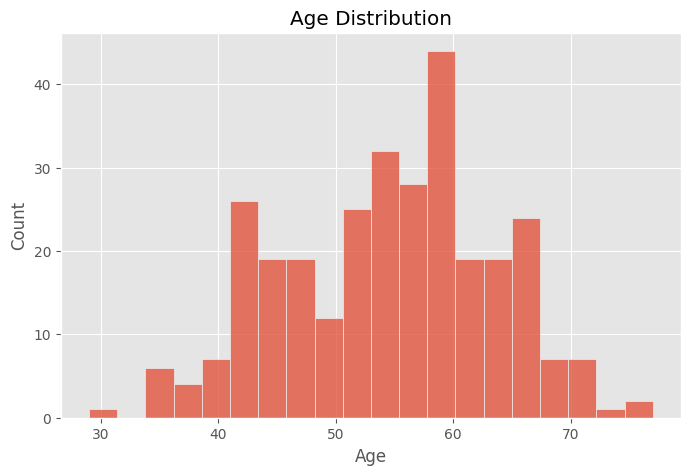

In [11]:
# Age Distribution of Patients
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=20)

plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')

plt.show()

### Observation

The distribution helps identify the age groups most represented in the dataset. Understanding age patterns is important because cardiovascular risk generally increases with age.

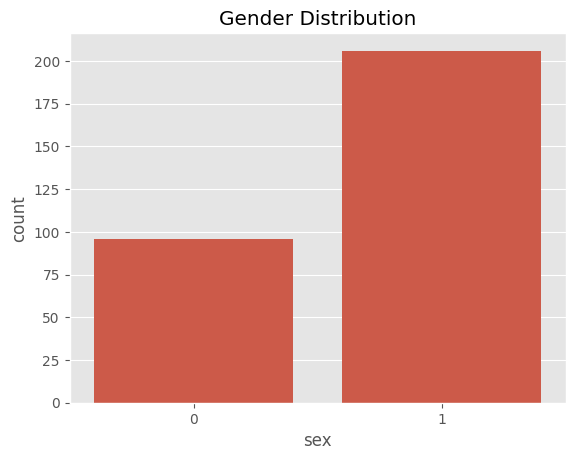

In [12]:
#GENDER DISTRIBUTION
sns.countplot(x='sex', data=df)

plt.title('Gender Distribution')
plt.show()

### Observation

This analysis helps determine whether the dataset contains a balanced representation of male and female patients. 1- F0R MALE , 0 - FOR FEMALE

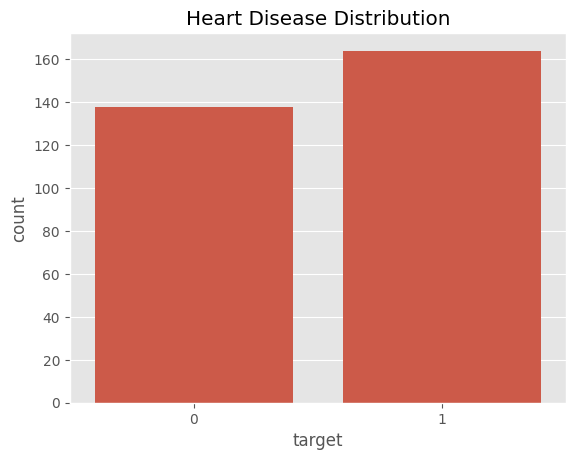

In [13]:
# Heart Disease Presence
sns.countplot(x='target', data=df)

plt.title('Heart Disease Distribution')
plt.show()

### Observation

This visualization shows the proportion of patients diagnosed with heart disease compared to those without the condition.

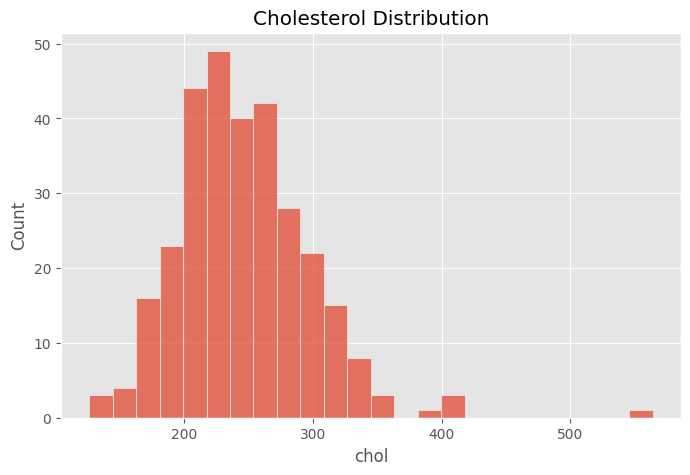

In [14]:
# Cholesterol Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['chol'])

plt.title('Cholesterol Distribution')
plt.show()

### Observation

Cholesterol is an important cardiovascular risk indicator. The distribution highlights the range and concentration of cholesterol levels among patients.

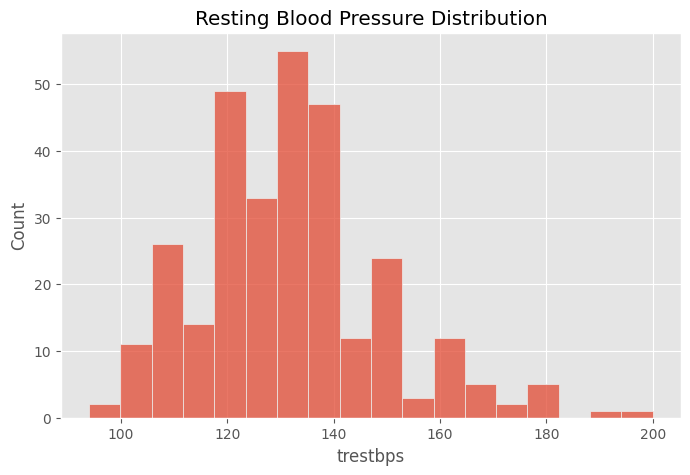

In [15]:
# Resting Blood Pressure Analysis
plt.figure(figsize=(8,5))
sns.histplot(df['trestbps'])

plt.title('Resting Blood Pressure Distribution')
plt.show()

### Observation

Resting blood pressure helps identify hypertension patterns, which are often associated with cardiovascular complications.

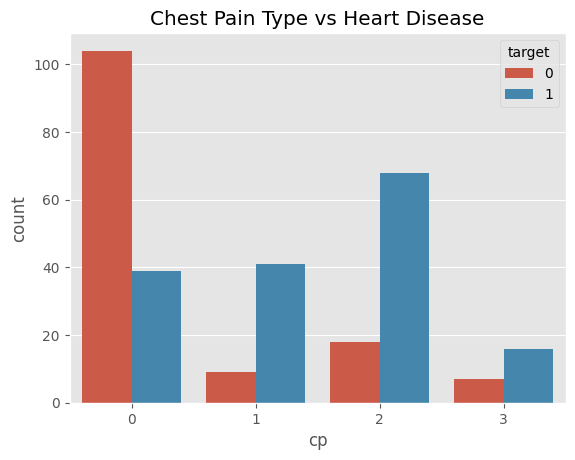

In [16]:
# Chest Pain Type Analysis
sns.countplot(
    x='cp',
    hue='target',
    data=df
)

plt.title('Chest Pain Type vs Heart Disease')
plt.show()

### Observation

Different chest pain types may indicate varying levels of cardiovascular risk. Comparing chest pain categories with heart disease status can reveal important patterns.

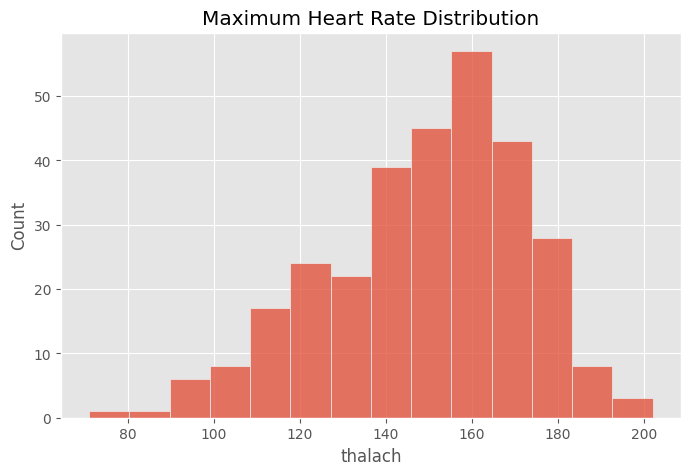

In [17]:
# Maximum Heart Rate Achieved
plt.figure(figsize=(8,5))
sns.histplot(df['thalach'])

plt.title('Maximum Heart Rate Distribution')
plt.show()

### Observation

Maximum heart rate provides insight into cardiovascular performance and exercise response.

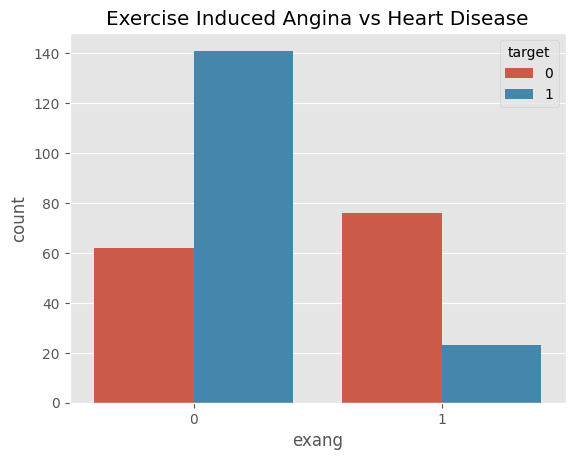

In [19]:
# Exercise Induced Angina
sns.countplot(
    x='exang',
    hue='target',
    data=df
)

plt.title('Exercise Induced Angina vs Heart Disease')
plt.show()


### Observation

Exercise-induced angina is often associated with restricted blood flow and may serve as an important indicator of heart disease risk.

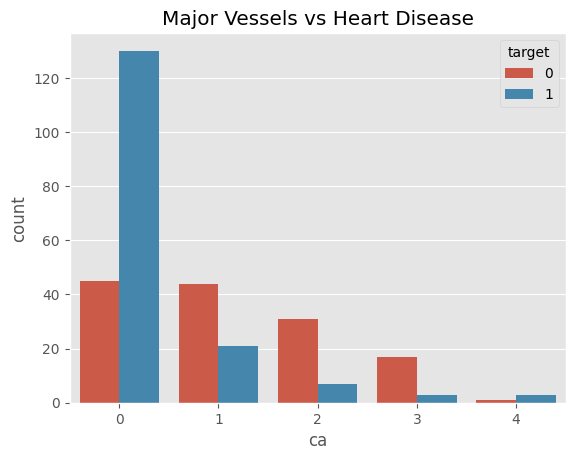

In [20]:
# Number of Major Vessels (ca)
sns.countplot(
    x='ca',
    hue='target',
    data=df
)

plt.title('Major Vessels vs Heart Disease')
plt.show()

### Observation

The number of major vessels may provide insights into the severity of coronary artery disease.

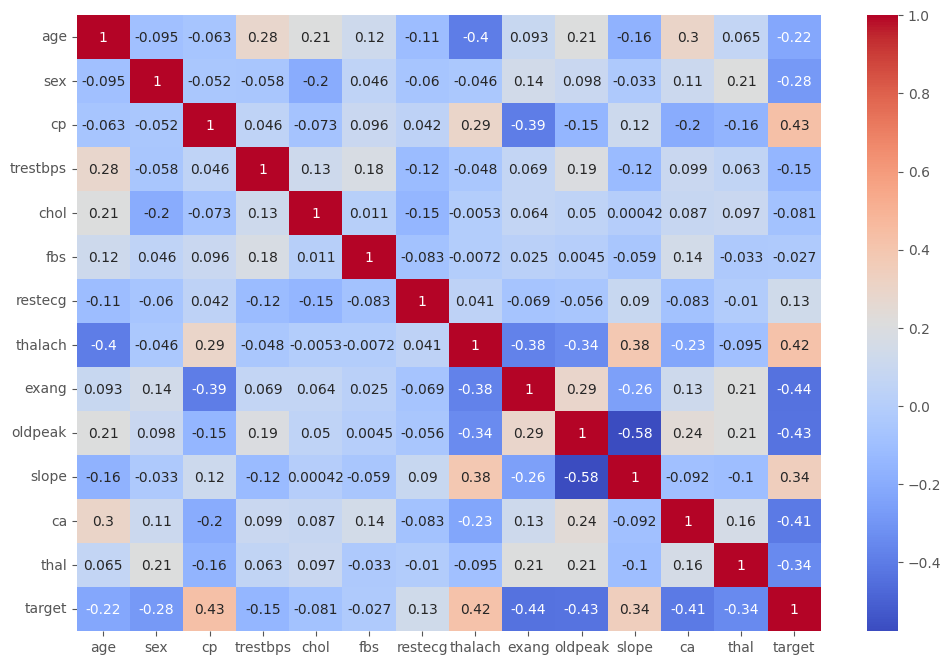

In [21]:
# Correlation Analysis
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()

### Observation

Correlation analysis helps identify variables that have strong positive or negative relationships with heart disease.

# Business Insights

1. Age remains an important factor, with heart disease becoming more common among middle-aged and older individuals.

2. Certain chest pain categories show a stronger association with heart disease diagnosis.

3. Exercise-induced angina appears to be an important clinical indicator of cardiovascular risk.

4. Cholesterol and blood pressure continue to play a significant role in overall heart health.

5. The number of major vessels affected provides valuable insight into disease severity.

6. Heart disease risk is rarely driven by a single factor and is often influenced by multiple clinical indicators simultaneously.

7. Early identification of high-risk patients can significantly improve treatment outcomes and reduce long-term healthcare costs.

# Recommendations

1. Increase awareness and screening programs for individuals in higher-risk age groups.

2. Encourage routine monitoring of cholesterol and blood pressure levels.

3. Promote lifestyle modifications such as improved diet, physical activity, and smoking cessation.

4. Develop risk assessment frameworks that consider multiple clinical indicators rather than relying on a single measurement.

5. Prioritize early intervention programs for patients exhibiting multiple cardiovascular risk factors.

# Conclusion

The analysis identified several important factors associated with heart disease, including age, chest pain characteristics, exercise-induced angina, cholesterol levels, and vascular conditions. These findings highlight the importance of early detection and preventive healthcare strategies. By leveraging data-driven insights, healthcare providers can improve patient outcomes and support more effective cardiovascular disease management.